# 5. Neuronale Netze

**KI1-Projekt 308** — California Housing Datensatz

**Schwerpunkt P2:** simultane Hyperparameteroptimierung und Featureengeneering

Dieses Notebook dient dem Anknüpfen der Erkenntnisse aus 05_flo_NN, 05_Neural_Network_Felix, 05_Neural_Network_Koja und einer Simultan-Optimierung der Hyperparameter sowie weiterem Featureengeneering.
Als nächster logischer Schritt bietet sich aufbauend auf den Erkenntnissen von Felix H. die Analyse durch Bayesianische Optimierung an, um noch Recheneffizienter mögliche Hyperparamter untersuchen zu können.


### Bayesianische Optimierung 
Die Idee: 
Beim Training eines neuronalen Netzes sind zuvor Auswirkungen der Änderungen der Kernrate und Neuronenanzahl auf den Loss unbekannt -> Blackbox. Die Optimierung über den [keras_tuner] nutzt ein statistisches Modell (Gauß-Prozess Q2) un schätzt für jede Hyperparameterkombination die erwartete Treffergenauigkeit und die Unsicherheit des Modells. Die Akquisitionsfunktion entscheidet über den als nächstes getesteten Punkt und wägt dabei zwischen Nähe zu vielverprechenden Werten und der Erkundung neuer Bereiche mit hoher Unsicherheit ab.  
Der Keras BayesianOptimization-Tuner testet zunächst zufällige Hyperparameterkombinationen. Dann berechnet er vielverprechende Kombinationen aus den bisherigen Ergebnissen. Mit diesen Prametern wird ein Netz trainiert und das Ergebnis den vorigen Ergebnissen hinzugefügt. Anschlißend beginnt die Berechnung der vielverprechenden Kombinationen erneut bis max-trials erreicht ist.   
Der Geschwindigkeitszuwachs erfolgt dabei durch die Möglichkeit des Abbruchs nach weniger als der maximalen Epochenanzahl, sofern ein Netz als nicht vielversprechend interpretiert wird.
Internetquelle
Name, Vorname (Erscheinungsjahr): Vollständiger Titel, [online] direkter Link [Datum des
Abrufs].  

Q1: Jasper Snoek, Hugo Larochelle, Ryan P. Adams (2012): Practical Bayesian Optimization of Machine Learning Algorithms [online] https://papers.nips.cc/paper_files/paper/2012/hash/05311655a15b75fab86956663e1819cd-Abstract.html[23.03.2026]  

Q2: Jochen Görtler, Rebecca Kehlbeck, Oliver Deussen (2019): A Visual Exploration of Gaussian Processes [online] https://distill.pub/2019/visual-exploration-gaussian-processes/

Zunächst erfolgt eine Aufteilung der Daten. Der Einfach- und Vergleichbarkeit wegen wird der gleiche Code wie in 05_Neural_Network_Felix.ipynb verwendet.

## 5.1 Benötigte Pakete und Funktionen

In [2]:
###Code übernommen aus 05_Neural_Network_Felix.ipynb
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LinearRegression

from utils.data import load_and_clean_data, get_train_test_split
from utils.evaluation import evaluate_predictions, add_result, evaluate_test_predictions
from utils.plotting import plot_features_vs_target, plot_predicted_vs_actual, plot_residuals, save_fig

plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"python Version: {sys.version}")



TensorFlow Version: 2.21.0
Numpy Version: 2.2.6
Pandas Version: 2.3.3
Matplotlib Version: 3.10.8
python Version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


In [3]:

import keras_tuner as kt
from sklearn.metrics import r2_score

#falls nicht funktional, skalieren auf -1 bis 1 probieren

def build_tuner_model(hp):
    """Definiere das Modell mit Hyperparametern, die vom Keras Tuner optimiert werden sollen."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_standard.shape[1],)))
    
    # 1. Hyperparameter: Aktivierungsfunktion (tanh war gut, elu und relu als Alternativen)
    activation = hp.Choice('activation', values=['tanh', 'relu', 'elu'])
    
    # 2. Hyperparameter: Anzahl Neuronen Layer 1 
    units_1 = hp.Int('units_1', min_value=32, max_value=256, step=16) #min und max value bestimmen Anzahl der Neuronen/ Layer
    model.add(layers.Dense(units_1, activation=activation))
    
    # Optionaler Dropout gegen Overfitting (wird vom Tuner getestet)
    # Dropout: einzelne Neuronen zur Berechnung zufällig ausschließen, um overfitting zu verhindern.
    dropout_1 = hp.Float('dropout_1', min_value=0.0, max_value=0.3, step=0.1) #bis 30% können ausgeschlossen werden. 
    if dropout_1 > 0:
        model.add(layers.Dropout(dropout_1))
    
    # 3. Hyperparameter: Anzahl Neuronen Layer 2 
    units_2 = hp.Int('units_2', min_value=16, max_value=256, step=16)
    model.add(layers.Dense(units_2, activation=activation))
    
    # 5. Hyperparameter: Anzahl Neuronen Layer 3
    #testweise einführung eines weiteren Layers 
    units_3 = hp.Int('units_3', min_value=16, max_value=256, step=16)
    model.add(layers.Dense(units_3, activation=activation))

    # Output Layer
    model.add(layers.Dense(1))
    
    # 4. Hyperparameter: Lernrate (Logarithmische Suche im relevanten Bereich)
    learning_rate = hp.Float('learning_rate', min_value=1e-3, max_value=1e-2, sampling='log') #Standart Größenbereich
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

## 5.2 Daten laden und transformieren + skalieren
Die Daten werden in Trainings und Testdaten gesplitet. Ein Teil Trainingsdatensatzes wird als Validierungsdatensatz verwendet. Der aufgeteilte Datensatz erhält dann folgende Umfänge und Features:

In [4]:
###Code übernommen aus 05_Neural_Network_Felix.ipynb
df = load_and_clean_data()
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")
###Code übernommen aus 05_Neural_Network_Felix.ipynb
X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")
###Code übernommen aus 05_Neural_Network_Felix.ipynb
X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 5.3 Neuronale Netze trainieren


Die bisherige Analyse ergab eine optimale Lernrate zwischen .001 und 0.01. Der nächste Schritt zur effizienteren Suche eines geeigneten NN ist statt random-, grid search die Verwendung der in keras_tuner enthaltenen Funktion zu Bayesianischer Optimierung. 
Hierzu half der KI-Promt: "Welche Möglichkeiten zur Simultan-optimierung sind für ein Neuronales Netz nach Versuchen mit grid-, und random search noch geeignet?".
Der nächste logische Schritt bedurfte einiges an Recherche. 

Für eine bessere Übersichtlichkeit des Ordners, erkläre ich die verwendeten Hyperparamtermodifikationen und gebe nicht für jede Variante den vollständigen Code erneut an (Beispielsweise Änderung der Epochenanzahl). 


### Information zu Keras-tuner
Quelle: Luca Invernizzi, James Long, Francois Chollet, Tom O'Malley, Haifeng Jin (2019): Getting started with KerasTuner https://keras.io/keras_tuner/getting_started/

### Early Stopping
Eine Idee aus der Untersuchung der Neuronalen Netze ist die Nutzung von "EarlyStopping". Diese ist eine Funktion zur drastischen Reduktion der Rechenzeit, durch abbrechen nicht zielführender Stränge nach weniger als der maximalen Epochenanzahl.  
Es wurden Standartwerte oder von KI empfohlene Werte für Berechnung verwendet.  
In der Implimentierung wird der Loss der Funktion auf den Validierungsdaten als Änderungswert herangezogen. Ist die Änderung nicht mehr groß genug, wird die Berechnung abgebrochen.  
Gleichzeitig wird ein lr_scheduler für dynamische Anpassungen der Lernrate verwendet. 
Quelle: https://keras.io/api/callbacks/early_stopping/ (Zugriff am 24.03.2024, keine Autoren oder Erscheinungsdatum bekannt)

### 5.3.1 Bayesianische Optimierung 

In [9]:
#learning rate (inzwischen funktional)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6 
)
early_stopping = keras.callbacks.EarlyStopping(                             
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1       #mit behalten der besten Gewichte für Reproduktion
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     # MSE auf den Validierungsdaten minimieren
    max_trials=15,            # Anzahl der zu testenden Kombinationen
    num_initial_points=5,     # zunächst 5 Random-Suchen um Bereich "kennen zu lernen"
    directory='tuning_dir',     
    project_name='california_housing_bayes',
    overwrite=True            # auf false, wenn man abgebrochenes tuning fortsetzen will
)

print("Starte Hyperparameter-Tuning...")
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,               # Maximal Epochen, meist greift EarlyStopping früher
    batch_size=32,            
    callbacks=[early_stopping, lr_scheduler],
    verbose=1                 #anzeige eines Ladebalkens
)

# Beste Parameter werden hier ausgegeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Layer 3 Neuronen: {best_hps.get('units_3')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")

Trial 15 Complete [00h 00m 46s]
val_loss: 0.19709978997707367

Best val_loss So Far: 0.1907920390367508
Total elapsed time: 00h 11m 30s

Beste Hyperparameter gefunden:
- Aktivierung: tanh
- Layer 1 Neuronen: 256
- Layer 1 Dropout: 0.2
- Layer 2 Neuronen: 192
- Layer 3 Neuronen: 224
- Lernrate: 0.00100


Nch der Suche der besten Hyperparameter werden die Modelle trainiert.

### Stärkstes Einzelmodell

Hinweis: Tuner wird in voriger Zelle initialisiert. Kurz warten und dann die nächsten zellen ausführen, falls Fehlermeldung eines fehlenden Tuners erscheint.


Trainiere finales Modell mit den besten Parametern
Epoch 66: early stopping
Restoring model weights from the end of the best epoch: 51.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.1966
MAE:           0.3018
R² Score:      0.7836


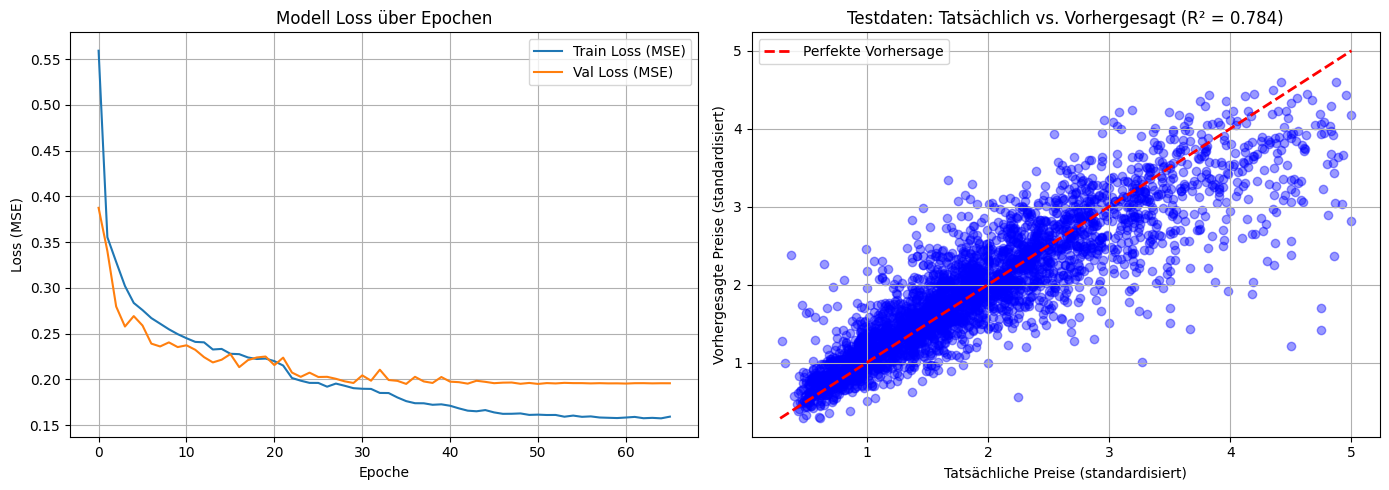


Bestes Modell gespeichert unter: best_keras_tuner_model.h5


In [10]:
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 # Auf 1 setzen für Epochen-Output
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0) #verbose auf 1 für aktuellen stand
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")


#plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage) wird eingefügt durch:
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Bestes Modell speichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)
print(f"\nBestes Modell gespeichert unter: {model_path}")

Nur Loss Plot

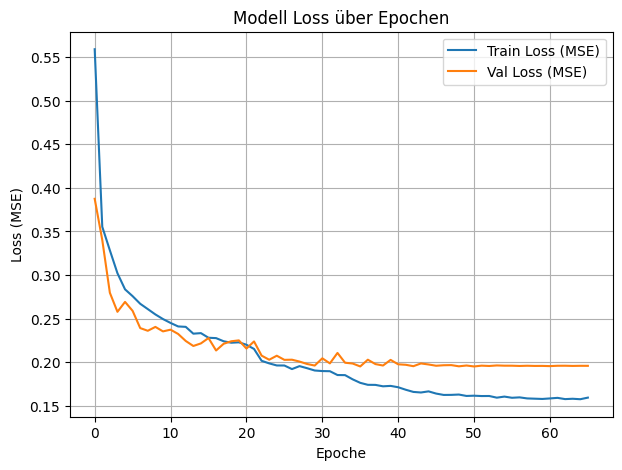


Bestes Modell gespeichert unter: best_keras_tuner_model.h5


In [23]:
# Plot: Trainings- und Validierungsverlauf (L2 Loss / MSE)
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Modell Loss über Epochen')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoche')
plt.legend()
plt.grid(True)
plt.show()

# Bestes Modell speichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)
print(f"\nBestes Modell gespeichert unter: {model_path}")

Wie zu sehen ist, wird der Abfall des Loss auf den Trainingsdaten fortlaufend kleiner, der auf den Validierungsdaten stagniert allerdings.   Im Sinne der Rechenzeit könnte man die Sensibilität des Earlystoppings verringern und das Training früher abbrechen. Ziel allerdings in akzeptablen Rechenzeiten sehr gute Ergebnisse zu erreichen. 

### Ensemble der besten fünf Modelle
Da das stärkste Modell noch nicht die allerbesten Ergebnisse liefert, nutzen wir als Resultat der Überlegung der vorigen Notebooks ein ensemble der stärksten fünf Neuronalen Netze.

Beste Modelle gespeichert in: C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-27_11-05-49



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2947
Ensemble R² Score: 0.7907


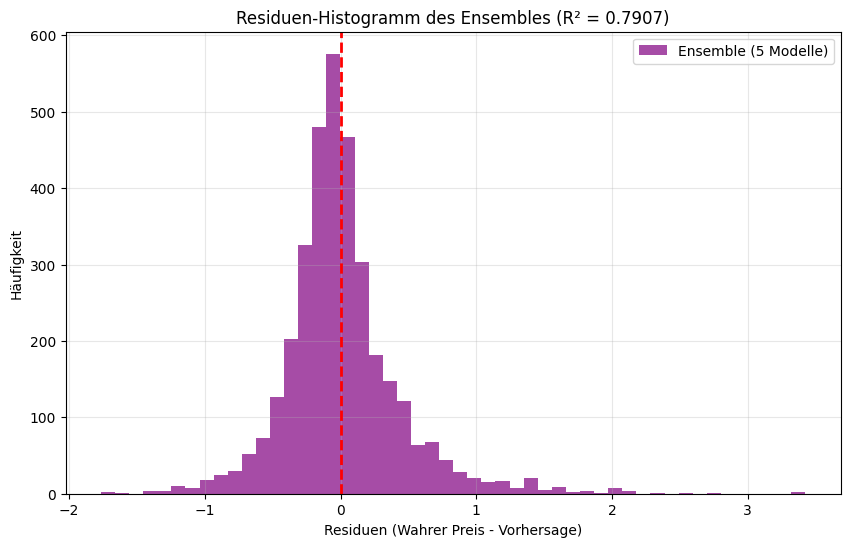

In [11]:
import os
from datetime import datetime


base_model_dir = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") # Zeitstempel im Namen dient der späteren Zuordnung der Ensembles 
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Beste Modelle gespeichert in: {current_run_dir}\n")

# vorher trainierte Modelle aufrufen
num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

#ENSEMBLE BILDEN 
# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")

#RESIDUEN PLOTTEN
plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Das Residuendiagramm zeigt eine Zentrierung der Werte um die Nulllinie. Das Modell hat demnach keinen systematischen Bias und unterschätzt Werte ähnlich oft, wie es sie überschätzt.   
Obgleich der Großteil des Fehlers in einem engen Bereich liegt, zeigt er keine perfekte Normalverteilung, sondern hat "heavy tails".
Eine solche leicht Rechtsschiefe Verteilung bedeutet, dass die Preise der Häuser im Zweifel leicht unterschätzt werden.  
Es sind auch einige Outlier (Residuen>2) zu erkennen deren Preis massiv unterschätzt wurde. Dies könnte an dem Fehlen von Features liegen, welche diese Preissteigungen erklären könnten.

Bei der Durchführung zeigt sich ein relativ stabiles Resultat im Bereich für R^2 ungefähr 79%, das nur geringfügig bei Variation der Parameter abweicht. 



## 5.3.2 Verändertes Featureengeneering

Ki Prmopt: "Wie kann ich die Performance des R^2 durch Featureengeneerning auf über 0.8 bringen?"
Idee: Die Features vor dem Training des neuronalen Netzes miteinander verrrechnen.  
Das ist bereits geschehen bei AveRooms und AveOccup. Nun wird dies auch durchgeführt mit "AveBedrms"/"AveRooms" = "Bedrooms_per_Room"
   - Tipp von Ki: Population logarithmisch betrachten und Nullfehler vermeiden durch +1
Der restliche Code bleibt zunächst unverändert, beziehungsweise die Kommentare werden etwas zusammengeführt an unveränderten Stellen.
   - Ergebnis: R^2 = 0.7922
Ein weiterer vorgenommener Schritt ist die Anpassung der Architektur. Dazu wird eine geringere Tiefe zur Unterbindung des gradient vanishing und zur Stabilisierung der Berechnung verwendet.
Die dadurch verringerte Rechenzeit wird nun genutzt um eine noch höhere Breite (mehr Neuronen pro Layer) zu erzielen.
Bemerkung: Die Änderung wurde zurückgenommen und der Layer wieder hinzugefügt.  
Ein Drop-out-layer verhindert dabei das Overfitting der Daten.


#


In [13]:

df = load_and_clean_data()

# geografische Features
# Koordinaten der Zentren (Breitengrad, Längengrad)
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
# Distanz zu San francisco und Los Angeles
df['Dist_to_SF'] = np.sqrt((df['Latitude'] - sf_lat)**2 + (df['Longitude'] - sf_lon)**2)
df['Dist_to_LA'] = np.sqrt((df['Latitude'] - la_lat)**2 + (df['Longitude'] - la_lon)**2)
#Kombinationsfeature
df['Lat_x_Lon'] = df['Latitude'] * df['Longitude']

df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']

# Logarithmus der Bevölkerung 
df['Log_Population'] = np.log(df['Population'] + 1) # +1 um Nullfehler auszuschließen
# ------------------------------------------
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")

X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']


In [24]:

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     #MSE auf den Validierungsdaten minimieren
    max_trials=30,            # Anzahl der zu testenden Kombinationen
    num_initial_points=5,     
    directory='tuning_dir',
    project_name='california_housing_bayes',
    overwrite=True            
)

print("Starte Hyperparameter-Tuning...")
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,               # Maximal Epochen, meist greift EarlyStopping früher
    batch_size=32,            
    callbacks=[early_stopping, lr_scheduler],
    verbose=1                 #anzeige eines Ladebalkens
)

# Beste Parameter ausgeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")

Trial 30 Complete [00h 00m 39s]
val_loss: 0.20282228291034698

Best val_loss So Far: 0.18671642243862152
Total elapsed time: 00h 23m 20s

Beste Hyperparameter gefunden:
- Aktivierung: elu
- Layer 1 Neuronen: 240
- Layer 1 Dropout: 0.0
- Layer 2 Neuronen: 48
- Lernrate: 0.00459


### Stärkstes Einzelmodell


Trainiere finales Modell mit den besten Parametern...
Epoch 75: early stopping
Restoring model weights from the end of the best epoch: 60.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.1975
MAE:           0.3047
R² Score:      0.7827


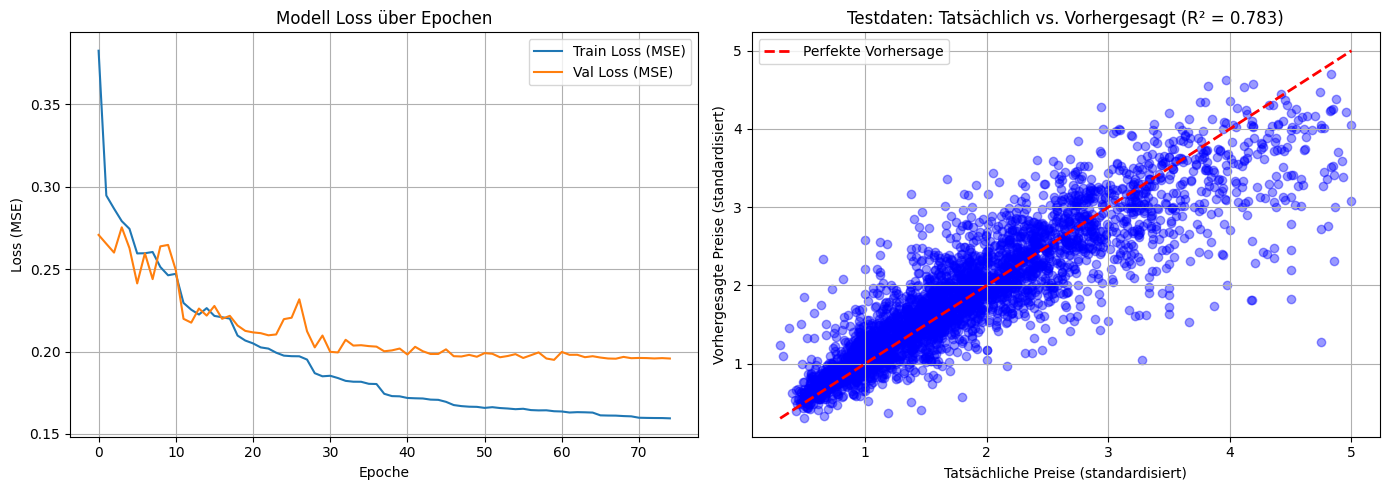


Bestes Modell gespeichert unter: best_keras_tuner_model.h5


In [25]:
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern...")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 # Auf 1 setzen für Epochen-Output
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0)
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage)
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modell abspeichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)
print(f"\nBestes Modell gespeichert unter: {model_path}")

Im linken Plot ist die Abnahme des Loss über die Epochen zu sehen. Es ist zu erkennen, dass weitere Epochen realtiv schnell keiner weiteren Verbesserung der Ergebnisse auf die Validierungsdaten helfen. Noch mehr Epochen helfen einem besseren Modell nicht weiter. Durch baysiansische Optimierung werden die meisten Durchgänge lang vorher abgebrochen, weshalb man die Epochenanzahl nicht weiter händisch verringern muss.


Top-Modelle dieses Durchlaufs landen in: C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-27_20-27-13



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2927
Ensemble R² Score: 0.7949


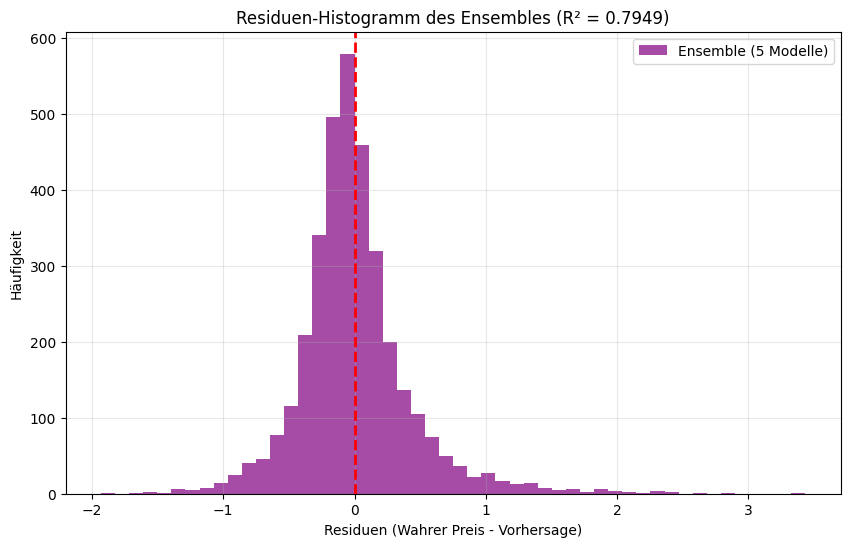

In [26]:
import os
from datetime import datetime

base_model_dir = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Top-Modelle dieses Durchlaufs landen in: {current_run_dir}\n")

num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")


plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Erneutes laden und ausgeben des R^2-Wertes erfolgt in folgender zelle: 

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


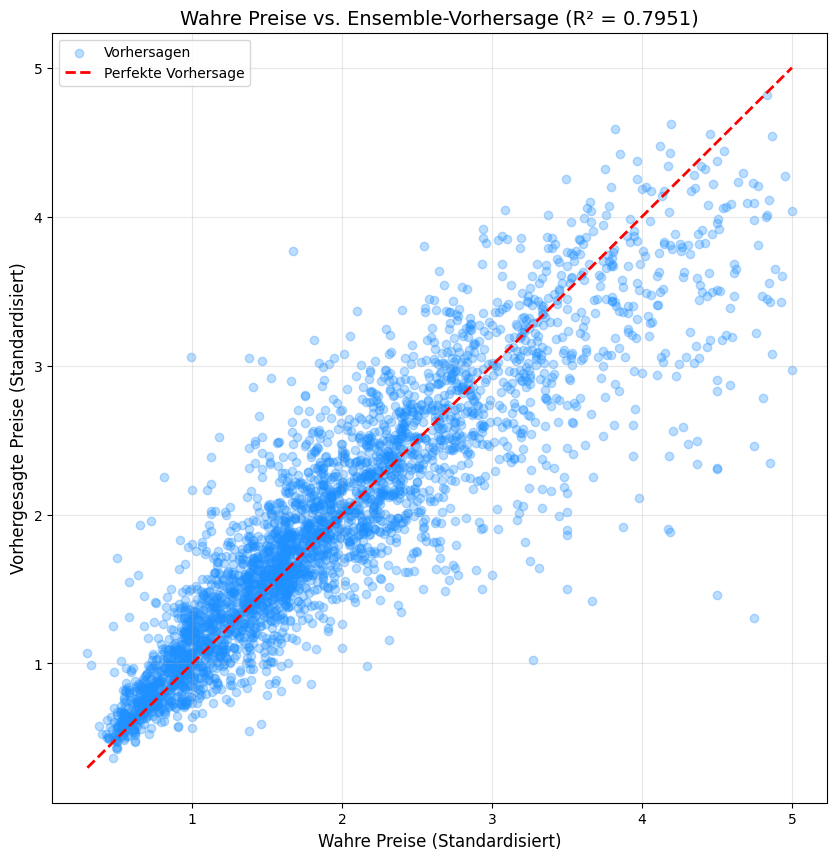

In [27]:
#Laden der Modelle:
#erste zeile mit jeweiligem zeitstempel
modell_ordner = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-20_21-29-14 R^2 = 0.7951"
dateien = ["modell_platz_1.h5", "modell_platz_2.h5", "modell_platz_3.h5", "modell_platz_4.h5", "modell_platz_5.h5"]

all_preds = []

# Jedes Modell einzeln laden und vorhersagen lassen
for datei in dateien:
    pfad = os.path.join(modell_ordner, datei)
    model = tf.keras.models.load_model(pfad, compile=False)
    
    # Vorhersage machen 
    preds = model.predict(X_test_standard).flatten()
    all_preds.append(preds)
    #print(f"{datei} geladen und berechnet.")

# Durchschnitt
y_ensemble_pred = np.mean(all_preds, axis=0)

ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
#print(f"\nEnsemble R² Score: {ensemble_r2:.4f}")

plt.figure(figsize=(10, 10))
# Streudiagramm der Vorhersagen vs Wahre Werte
plt.scatter(y_test_standard, y_ensemble_pred, alpha=0.3, color='dodgerblue', label='Vorhersagen')

# Perfekte Vorhersage-Linie (Diagonale)
min_val = min(np.min(y_test_standard), np.min(y_ensemble_pred))
max_val = max(np.max(y_test_standard), np.max(y_ensemble_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfekte Vorhersage')

plt.title(f'Wahre Preise vs. Ensemble-Vorhersage (R² = {ensemble_r2:.4f})', fontsize=14)
plt.xlabel('Wahre Preise (Standardisiert)', fontsize=12)
plt.ylabel('Vorhergesagte Preise (Standardisiert)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Die Einführung der Daten verbessert die Regression nur geringfügig. Die Fehler sind noch ähnlich groß. Auch die Rechtsschiefe Verteilung und die Outlier konnten so nicht unterbunden werden. Im Plot (Wahre Preise vs. vorhergesagte Preise) fallen diese Ausreißer rechts unten stark auf. Der Preis wird meist immer noch unterschätzt. Absolut gesehen verbessert das Featureengeneering allerdings die Regression.

Da das Featureengeneering die bisher stärkste Regression erlaubte, fragt sich ob der Informationszuwachs zufall ist, oder die zusätzlichen Features tatsächlich bei der Regression helfen.  
Zur Untersuchung der Einflüsse der neuen Features wird erneut ein Random Forest eingeführt.   
Auf diese Weise wird nicht blind berechnet, sondern eine Analyse des Nutzens durchgeführt.


### 5.3.3 Random Forest zur Featureanalyse

Zur sicherheit nochmal vollständige Dateneinlese:

In [28]:

df = load_and_clean_data()

# geografische Features
# Koordinaten der Zentren (Breitengrad, Längengrad)
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
# Distanz zu San francisco und Los Angeles
df['Dist_to_SF'] = np.sqrt((df['Latitude'] - sf_lat)**2 + (df['Longitude'] - sf_lon)**2)
df['Dist_to_LA'] = np.sqrt((df['Latitude'] - la_lat)**2 + (df['Longitude'] - la_lon)**2)
#Kombinationsfeature
df['Lat_x_Lon'] = df['Latitude'] * df['Longitude']

df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']

# Logarithmus der Bevölkerung 
df['Log_Population'] = np.log(df['Population'] + 1) # +1 um Nullfehler auszuschließen
# ------------------------------------------
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")

X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']


### Random Forest

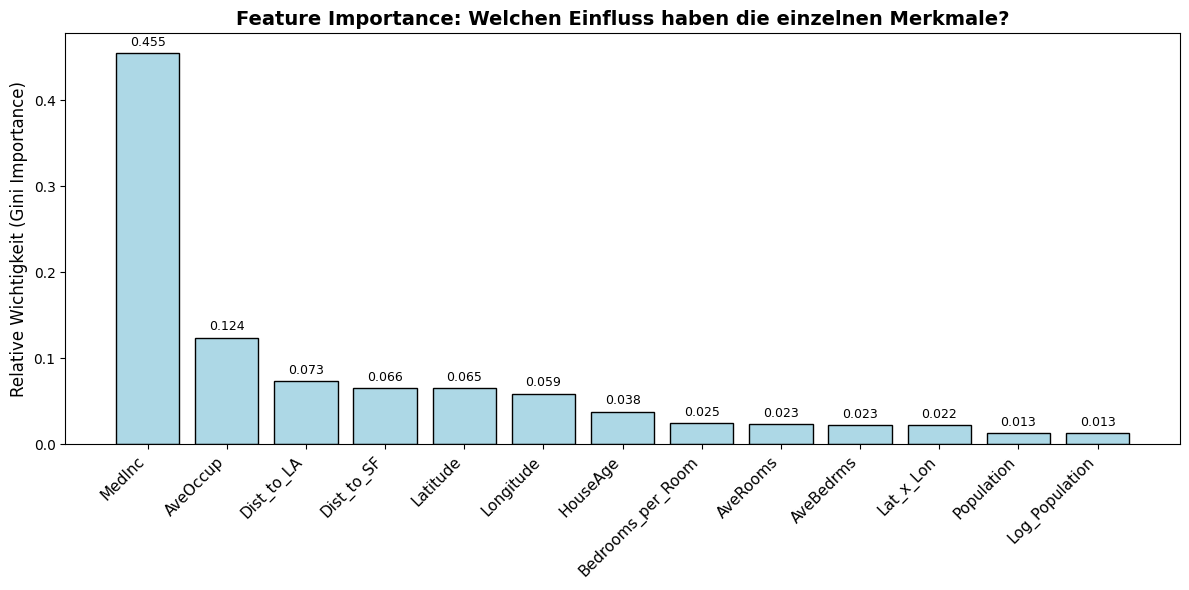

Random Forest R² Score auf Testdaten: 0.7995


In [29]:

from sklearn.ensemble import RandomForestRegressor

if isinstance(y_train, pd.DataFrame) or isinstance(y_train, pd.Series):
    y_train_rf = y_train.values.ravel()
else:
    y_train_rf = y_train.ravel()


# n_jobs=-1: alle Kerne desProzessors nutzen
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train_rf)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Absteigend sortieren

#absteigende Reihenfolge
sorted_features = [feature_names[i] for i in indices]
#Plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importance: Welchen Einfluss haben die einzelnen Merkmale?", fontsize=14, fontweight='bold')

# Balkendiagramm 
plt.bar(range(X_train.shape[1]), importances[indices], color='lightblue', edgecolor='black')

# Achsenbeschriftungen anpassen
plt.xticks(range(X_train.shape[1]), sorted_features, rotation=45, ha='right', fontsize=11)
plt.ylabel("Relative Wichtigkeit (Gini Importance)", fontsize=12)

# exakte Werte hinzufügen
for i, val in enumerate(importances[indices]):
    plt.text(i, val + 0.005, f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

y_rf_pred = rf.predict(X_test) 
print(f"Random Forest R² Score auf Testdaten: {r2_score(y_test, y_rf_pred):.4f}")

Zu sehen sind die Feature Importances und der R^2.
Der Random Forest erzielt hierbei ein minimal besseres Ergebnis als das Neuronale Netz (Differenz R^2 = 0.0044).  
Dem Plot zu entnehmen ist, dass einige Features nur wenig Beitrag von circa 1% am Informationsgewinn haben. Da jedes Feature auch für Rauschen sorgt, kann ein Feature ab einem Schwellwert mehr schaden als helfen. Die Idee ist deshalb den Datensatz ohne diese Features zu betrachten.  
  

Tabellarische Daten mit Unregelmässigkeiten, harten Kanten und schiefen Verteilungen lassen sich gut mit Entscheidungsbäumen beschreiben. Neuronale Netze performen besser auf "glatten", normalverteilten Daten.  
Eine Lösungsmöglichkeit wäre eine och weiter Verbesserte Datenaufbereitung. Beispielweise der Versuch weitere Ausreißer an der Definitionsgrenze heraus zu filtern. 
Man könnte auch statt des Standart-scaler oder MinMax-Scaler einen Powertransformer nutzen.  
Dieser ist stärker auf schiefen Datenverteilungen wie zum beispiel bei MedInc und Population als der StandardScaler.
Quelle 1: Yeo, I. K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. Biometrika, 87(4), 954-959
Quelle 2: Kuhn, M., & Johnson, K. (2013). Applied Predictive Modeling. Springer. (Kapitel 3: Data Pre-processing)  
  

Deshalb ist ein random Forest auch im Vorteil, da dieser unbeeinflusst von schiefen Datenverteilungen bleibt.  
Ein PowerTransformer wie er beispielsweise in Scikit learn enthalten ist, behebt das Problem mit der Schiefe und könnte zum Schulterschluss mit dem Random Forest führen.  
Eine weitere Möglichkeit könnte sein die Batch size zu variieren. Eine größere Batchsize führt zu ruhigerem Training, aber auch zu Overfitting. Es gilt daherr acht zu geben.
Bemerkung: Eine Variation der Batchsize führt zu keinen Verbesserungen. Dem Untersuchungsergebnissen der anderen Notebooks entsprechend wird hier bei 32 verblieben.


### 5.3.4 Training mit optimierten Features

Nun findet das Training des Neuronalen Netzes, mit bekanntem Code, unter Ausschluss der schwächsten Features zur Beschreibung des Datensatzes statt.


Trial 30 Complete [00h 00m 39s]
val_loss: 0.19958166778087616

Best val_loss So Far: 0.19167734682559967
Total elapsed time: 00h 23m 26s

Beste Hyperparameter gefunden:
- Aktivierung: elu
- Layer 1 Neuronen: 80
- Layer 1 Dropout: 0.1
- Layer 2 Neuronen: 256
- Lernrate: 0.00538

Trainiere finales Modell mit den besten Parametern...
Epoch 76: early stopping
Restoring model weights from the end of the best epoch: 61.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.1952
MAE:           0.3020
R² Score:      0.7852


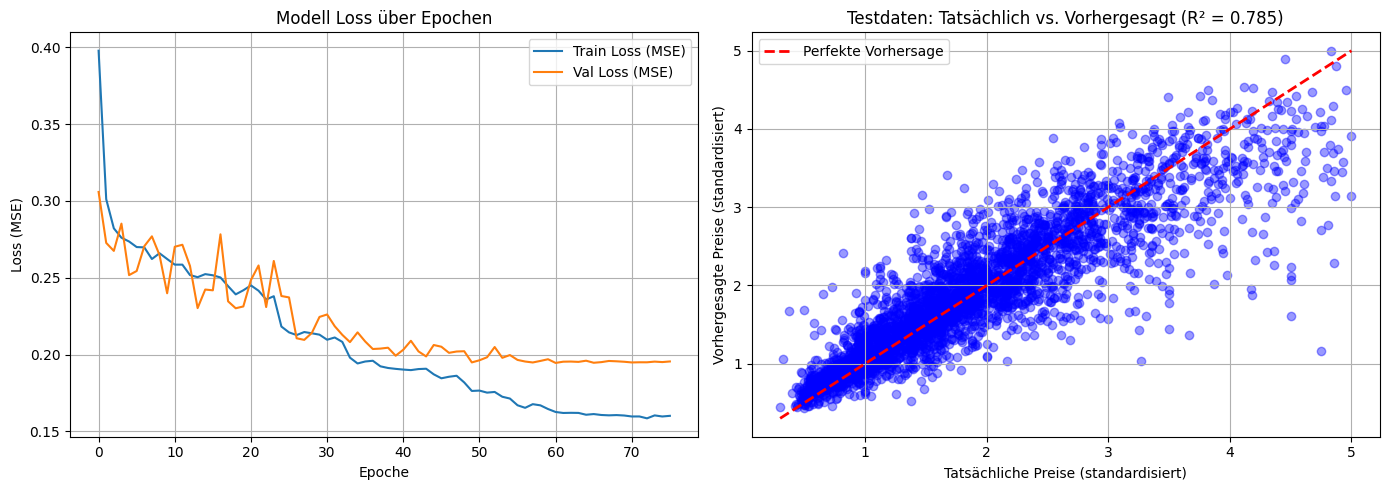

Top-Modelle dieses Durchlaufs landen in: C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-27_20-51-38



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2909
Ensemble R² Score: 0.7944


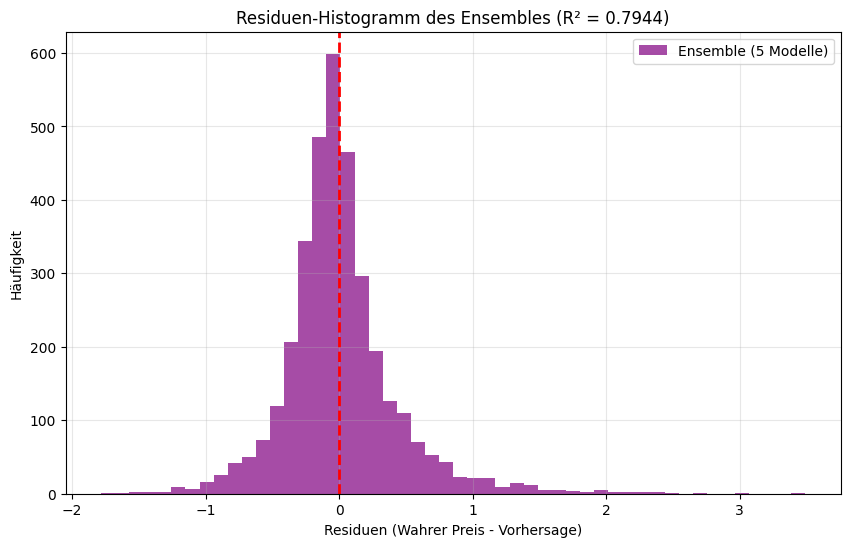

In [30]:
# Ausgeschlossene Features: Population, Log_Population
df.drop(columns=["Population", "Log_Population"])

#ab hier zusammengekürzter bekannter Code
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     
    max_trials=30,           
    num_initial_points=5,     
    directory='tuning_dir',
    project_name='california_housing_bayes',
    overwrite=True            
)
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,             
    batch_size=32,            
    callbacks=[early_stopping, lr_scheduler],
    verbose=1               
)

# Beste Parameter ausgeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern...")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0)
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage)
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modell abspeichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)

base_model_dir = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Top-Modelle dieses Durchlaufs landen in: {current_run_dir}\n")

num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")


plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Ergebnisse Feature drop 
Zunächst wurde eine Analyse ohne "Population" und "Log_Population" durchgeführt. Dies führt zu keiner Verbesserung bei R^2 und Loss.  
Entscheidung:  
Da die beiden schwächsten Features noch immer über 1% liefern, werden sie beibehalten für das Neuronale Netz. Neuronale Netze können auch aus kleinen Signalen noch Muster schließen, daher hilft es nicht sie zu beschneiden. Dies würde vermutlich erst weit unter einem Prozent zu einem spürbaren Ergebnis führen, da hier das Rauschen dem Informationsgewinn überwiegt.

Dieser Eindruck und auch die sehr geringe Hilfe der neu hinzugefügten Features wird zusätzlich durch die Korrealtionsanalyse unterstützt:
 

Gespeichert: results/eda_correlation_heatmap.png und results/eda_correlation_heatmap.pdf


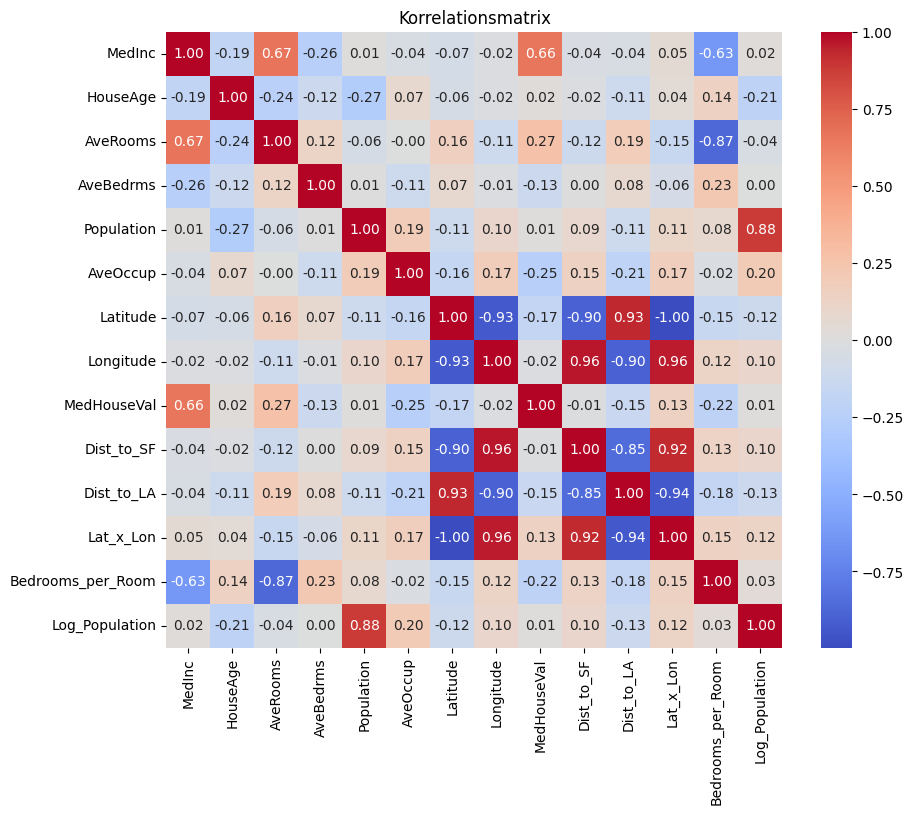

In [31]:
from utils.plotting import plot_correlation_heatmap
fig, ax = plot_correlation_heatmap(df, save_name="eda_correlation_heatmap")
plt.show()

Diese zeigt, dass die neu hinzugefügten Features aufgrund ihrer geringen Korrelation zur Zielvariable (MedHouseVal), wenig Einfluss auf die Genauigkeit des Modells haben.

### 5.4 Laden des besten Modells 

Wichtig: Zellen 6,7,9 und 40 ausführen!

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


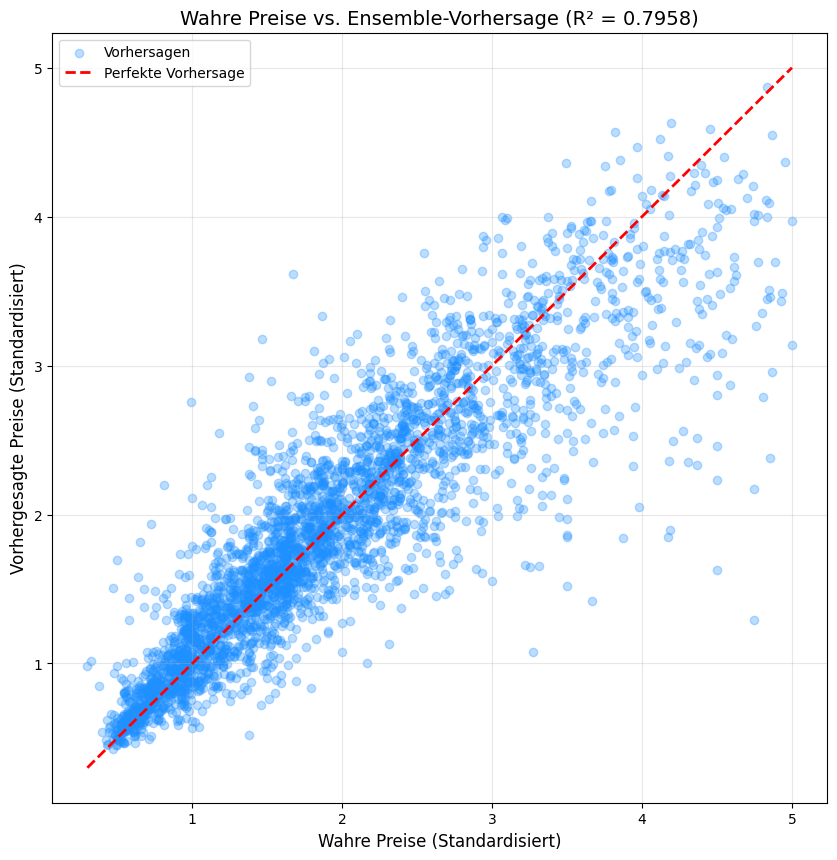

In [14]:
#Laden der Modelle:
import os
#erste zeile mit jeweiligem zeitstempel
modell_ordner = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-24_11-16-05 R^2  = 0.7958"
dateien = ["modell_platz_1.h5", "modell_platz_2.h5", "modell_platz_3.h5", "modell_platz_4.h5", "modell_platz_5.h5"]

all_preds = []

# Jedes Modell einzeln laden und vorhersagen lassen
for datei in dateien:
    pfad = os.path.join(modell_ordner, datei)
    model = tf.keras.models.load_model(pfad, compile=False)
    
    # Vorhersage machen 
    preds = model.predict(X_test_standard).flatten()
    all_preds.append(preds)
    #print(f"{datei} geladen und berechnet.")

# Durchschnitt
y_ensemble_pred = np.mean(all_preds, axis=0)

ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
#print(f"\nEnsemble R² Score: {ensemble_r2:.4f}")

plt.figure(figsize=(10, 10))
# Streudiagramm der Vorhersagen vs Wahre Werte
plt.scatter(y_test_standard, y_ensemble_pred, alpha=0.3, color='dodgerblue', label='Vorhersagen')

# Perfekte Vorhersage-Linie (Diagonale)
min_val = min(np.min(y_test_standard), np.min(y_ensemble_pred))
max_val = max(np.max(y_test_standard), np.max(y_ensemble_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfekte Vorhersage')

plt.title(f'Wahre Preise vs. Ensemble-Vorhersage (R² = {ensemble_r2:.4f})', fontsize=14)
plt.xlabel('Wahre Preise (Standardisiert)', fontsize=12)
plt.ylabel('Vorhergesagte Preise (Standardisiert)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fehlerwerte ausgeben:

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_standard, y_ensemble_pred)
mae = mean_absolute_error(y_test_standard, y_ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_test_standard, y_ensemble_pred))

print("--- Modell Evaluierung ---")
print(f"R² Score: {r2:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"RMSE:     {rmse:.4f}")

--- Modell Evaluierung ---
R² Score: 0.7958
MAE:      0.2895
RMSE:     0.4308


## Vergleich mit linearer Regression

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

result_lr = evaluate_predictions(
    y_train, lr.predict(X_train),
    y_test, lr.predict(X_test),
    "Lineare Regression (Referenz)"
)
add_result(result_lr)


  Lineare Regression (Referenz)
  R² Score:  Train = 0.6608  |  Test = 0.6442
  MAE:       Train = 0.4146  |  Test = 0.4221
  RMSE:      Train = 0.5594  |  Test = 0.5687


Zusammenfassung:    
Die besten Modelle des Neuronalen Netzes und der linearen Regression(als Vergleich) auf die Testdaten:  
--- Bestes Modell ---    
  R² Score: 0.7958                    
  MAE:      0.2895                  
  RMSE:     0.4308                  
---lineare Regression---  
  R² Score: 0.6326  
  MAE:      0.4341  
  RMSE:     0.5779  
  
Dieses Notebook baut auf vorherigen Analysen auf und fokussiert sich auf die Optimierung neuronaler Netze für den California Housing Datensatz durch Bayesianische Optimierung und erweitertes Feature Engineering. Die Hauptziele waren die simultane Hyperparameteroptimierung und die Verbesserung der Modellleistung über R² = 0.8 hinaus.

Schlüsselmethoden und Ansätze:
Bayesianische Optimierung: Verwendet Keras Tuner zur effizienten Suche nach optimalen Hyperparametern (z. B. Aktivierungsfunktionen, Neuronenanzahl, Dropout, Lernrate). Dies ermöglicht eine Blackbox-Optimierung mit Gauß-Prozessen, die Exploration und Exploitation balanciert und durch Early Stopping Rechenzeit spart.  
Feature Engineering: Ergänzung der Daten um geografische Features (z. B. Distanz zu SF/LA, Lat_x_Lon), Bedrooms_per_Room und Log_Population. Dies führte zu einer leichten Verbesserung der Modellleistung.
Ensemble-Ansatz: Kombination der besten 5 Modelle zur Reduzierung von Varianz und Verbesserung der Robustheit.
Vergleich mit anderen Modellen: Random Forest für Feature Importance-Analyse und lineare Regression als Baseline.
Wichtige Ergebnisse:  
Bestes Einzelmodell: R² ≈ 0.7958, MAE ≈ 0.2895, RMSE ≈ 0.4308 auf Testdaten.
Ensemble-Modell: Ähnliche Leistung mit R² ≈ 0.7958, zeigt zentrierte Residuen ohne systematischen Bias, aber mit rechtsschiefen Ausreißern (Unterschätzung hoher Preise). Das beste mit diesem Notebook erreichte Modell liegt noch immer minimal hinter dem Random Forest und dem besten gradient boosting Modell aus Notebook 03_Ensemble.ipynb.  
Feature Importance: Random Forest zeigt, dass geografische und demografische Features (z. B. MedInc, Latitude) dominant sind; neue Features tragen gering bei und verbessern die Leistung nur marginal.  
Vergleich: Neuronale Netze übertreffen lineare Regression (R² ≈ 0.6326) deutlich, liegen aber knapp hinter Random Forest (R² ≈ 0.8002). Feature-Dropping schwacher Features brachte keine Verbesserung.  
Grenzen: Trotz Optimierung bleibt R² unter 0.8; schiefe Datenverteilungen und Ausreißer limitieren die Leistung. Der nächste logische Schritt wären Versuche mit einem Powertransformer. Dieser kann verglichen mit dem standart-, oder min-max-scaler deutlich besser mit schiefen Verteilungen umgehen. Alternativ ließen sich die Daten auch händisch transformieren, um die Schiefe zu bekämpfen.   
Insgesamt demonstriert das Notebook die Stärken der Bayesianischen Optimierung für effiziente Hyperparameter-Tuning und bestätigt, dass neuronale Netze komplexe Muster besser erfassen als lineare Modelle, während Feature Engineering inkrementelle Verbesserungen ermöglicht.
